# Image Captioning on the Flicker8k Dataset

This notebook provides you with a rough structure for the Mini-Challenge on the topic of Image Captioning from the Deep Learning MSE course. Please make sure to follow the Project Setup steps to ensure reproducable results. Additionally familiarize yourself with the grading structure and project submission guidelines in the _DL-MPW-ImgCaptioning.pdf_ document. There you'll find all the information you should need.

If you have any questions please contact roman.studer@fhnw.ch

###  Team Name and Members
<span style="color: red;"><strong>TODO:</strong> Add your teamname and add the names of your team members</span>


### Some Guidelines

- You are allowed to use generative models (e.g. ChatGPT, Claude etc.) for code completion or suggestions. However, we require you to perfectly understand and control the code.
- You are **not** allowed to use the same or similar generative models for providing reflection on the achieved results. __You__ must reflect about what you see and build your own opinion about it.
- You are allowed to create additional python scripts to outsource code snippets to improve readability.

In [ ]:
from google.colab import files
uploaded = files.upload()   # select dataloader.py and other repo files


Saving test_captions.csv to test_captions.csv


In [ ]:
# create the folder first
!mkdir -p ./data/images
!mkdir -p ./data/splits

# then unzip into it
!unzip archive.zip -d ./data/images



Streaming output truncated to the last 5000 lines.
  inflating: ./data/images/Images/2844846111_8c1cbfc75d.jpg  
  inflating: ./data/images/Images/2844963839_ff09cdb81f.jpg  
  inflating: ./data/images/Images/2845246160_d0d1bbd6f0.jpg  
  inflating: ./data/images/Images/2845691057_d4ab89d889.jpg  
  inflating: ./data/images/Images/2845845721_d0bc113ff7.jpg  
  inflating: ./data/images/Images/2846037553_1a1de50709.jpg  
  inflating: ./data/images/Images/2846785268_904c5fcf9f.jpg  
  inflating: ./data/images/Images/2846843520_b0e6211478.jpg  
  inflating: ./data/images/Images/2847514745_9a35493023.jpg  
  inflating: ./data/images/Images/2847615962_c330bded6e.jpg  
  inflating: ./data/images/Images/2847859796_4d9cb0d31f.jpg  
  inflating: ./data/images/Images/2848266893_9693c66275.jpg  
  inflating: ./data/images/Images/2848571082_26454cb981.jpg  
  inflating: ./data/images/Images/2848895544_6d06210e9d.jpg  
  inflating: ./data/images/Images/2848977044_446a31d86e.jpg  
  inflating: ./data

## Project Setup


### 1. Create the virtual environment

Create a new environment and install the necessary dependencies listed in `requirements.txt`. Make sure you can import the libraries in the code cell below and that yout pytorch installation can run on your GPU.

In [ ]:
# imports
import textwrap

import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision

from dataloader import (
    build_tokenizer_from_split,
    create_caption_dataloader
)
from tokenizer import tokenize

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

# TODO: Add your own imports here, if needed.

torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


### 2. Download the dataset
The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k). In the zip folder on Moodle you find the basic structure with `captions.txt` and the `data/splits`-folder, but without images in the `data/ìmages`-folder. Make sure to download all the images and placing them in the folder `data/images/`.
The train test split is already provided for you and handled by the provided `dataloader.py` script. Test and train split image lists and corresponding captions are located in the `data/splits/` folder. Don't modify this split.

<img src="data_structure.png"/>

## Dataloader, Tokenizer

The repository includes a `Dataset`-class (`Flickr8kCaptionsDatasetBase`) and `DataLoader`'s that are based on this specific structure of the data directory. You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders. You can configure it with the `tokenizer` provided in the repo. The `tokenizer` performs some preprocessing steps of the captions. It also creates a vocabulary from the training data and then provides a mapping from the words to tokens. Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:
| Word    | ID | Role |
| --------| ---|----- |
| `<pad>`  | 0 | padding for filling up sequence to a given length in a mini-batch. |
| `<bos>`  | 1 | beginning of sentence - each tokenized sentence should start with `<bos>`, i.e. also the generated ones. |
| `<eos>`  | 2 | end of sentence - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. |
| `<unk>`  | 3 | unknown - not available in vocabulary |

Furthermore, specify your transforms used for preprocessing and augmenting the images and pass them to the `create_caption_dataloader`-method.
The mini-batches created by the dataloader have the following structure: `(images, captions, lengths, image_ids, raw_captions)`. Captions are built from the training vocabulary only, and `lengths` may let you mask padding tokens in the loss.


In [ ]:
# Transforms
from torchvision import transforms

IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")

def build_train_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            # START - MODIFY / EXTEND THIS PART
            transforms.Resize((256, 256)),              # resize slightly larger
            transforms.RandomCrop(IMAGENET_SIZE),       # crop to 224×224
            transforms.RandomHorizontalFlip(),          # augmentation
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            #transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            # END - MODIFY / EXTEND THIS PART
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def build_test_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalization for visualization."""
    mean_tensor = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_tensor = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_tensor + mean_tensor).clamp(0, 1)

In [ ]:
!mv /content/data/images/Images/* /content/data/images/


In [ ]:
# TODO: ADJUST PATH TO data_dir IF NEEDED
data_dir = "/content/data"

# TODO: SET REASONABLE VALUES FOR THE FOLLOWING PARAMETERS
MIN_WORD_FREQ = 5
MAX_LEN = 40
BATCH_SIZE = 32

In [ ]:
# TODO: POSSIBLY USE YOUR OWN TOKENIZER AND SET IT TO tokenizer=YourTokenizer(...)
# Make sure to build the vocabulary only from training captions to avoid test leakage.

tokenizer = build_tokenizer_from_split(split="train", data_dir = data_dir, min_freq=MIN_WORD_FREQ)

train_loader = create_caption_dataloader(
    split="train",
    data_dir = data_dir,
    tokenizer=tokenizer,
    transform = build_train_transforms(),
    batch_size = BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all")
test_loader = create_caption_dataloader(
    split="test",
    data_dir = data_dir,
    tokenizer=tokenizer,
    transform = build_test_transforms(),
    batch_size = BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="random")

images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Number of training examples: {len(train_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))

print(f"Number of test examples: {len(test_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

Vocabulary size: 2,649
Number of training examples: 32,365
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [19, 19, 14, 17, 10, 11, 16, 11, 5, 17, 10, 11, 12, 13, 21, 16, 12, 13, 18, 16, 15, 11, 13, 15, 11, 12, 12, 10, 16, 11, 14, 13]
Number of test examples: 1,618
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [9, 11, 7, 17, 12, 10, 13, 7, 9, 11, 20, 15, 13, 28, 10, 10, 12, 9, 20, 7, 18, 14, 9, 11, 19, 9, 9, 14, 13, 11, 13, 16]


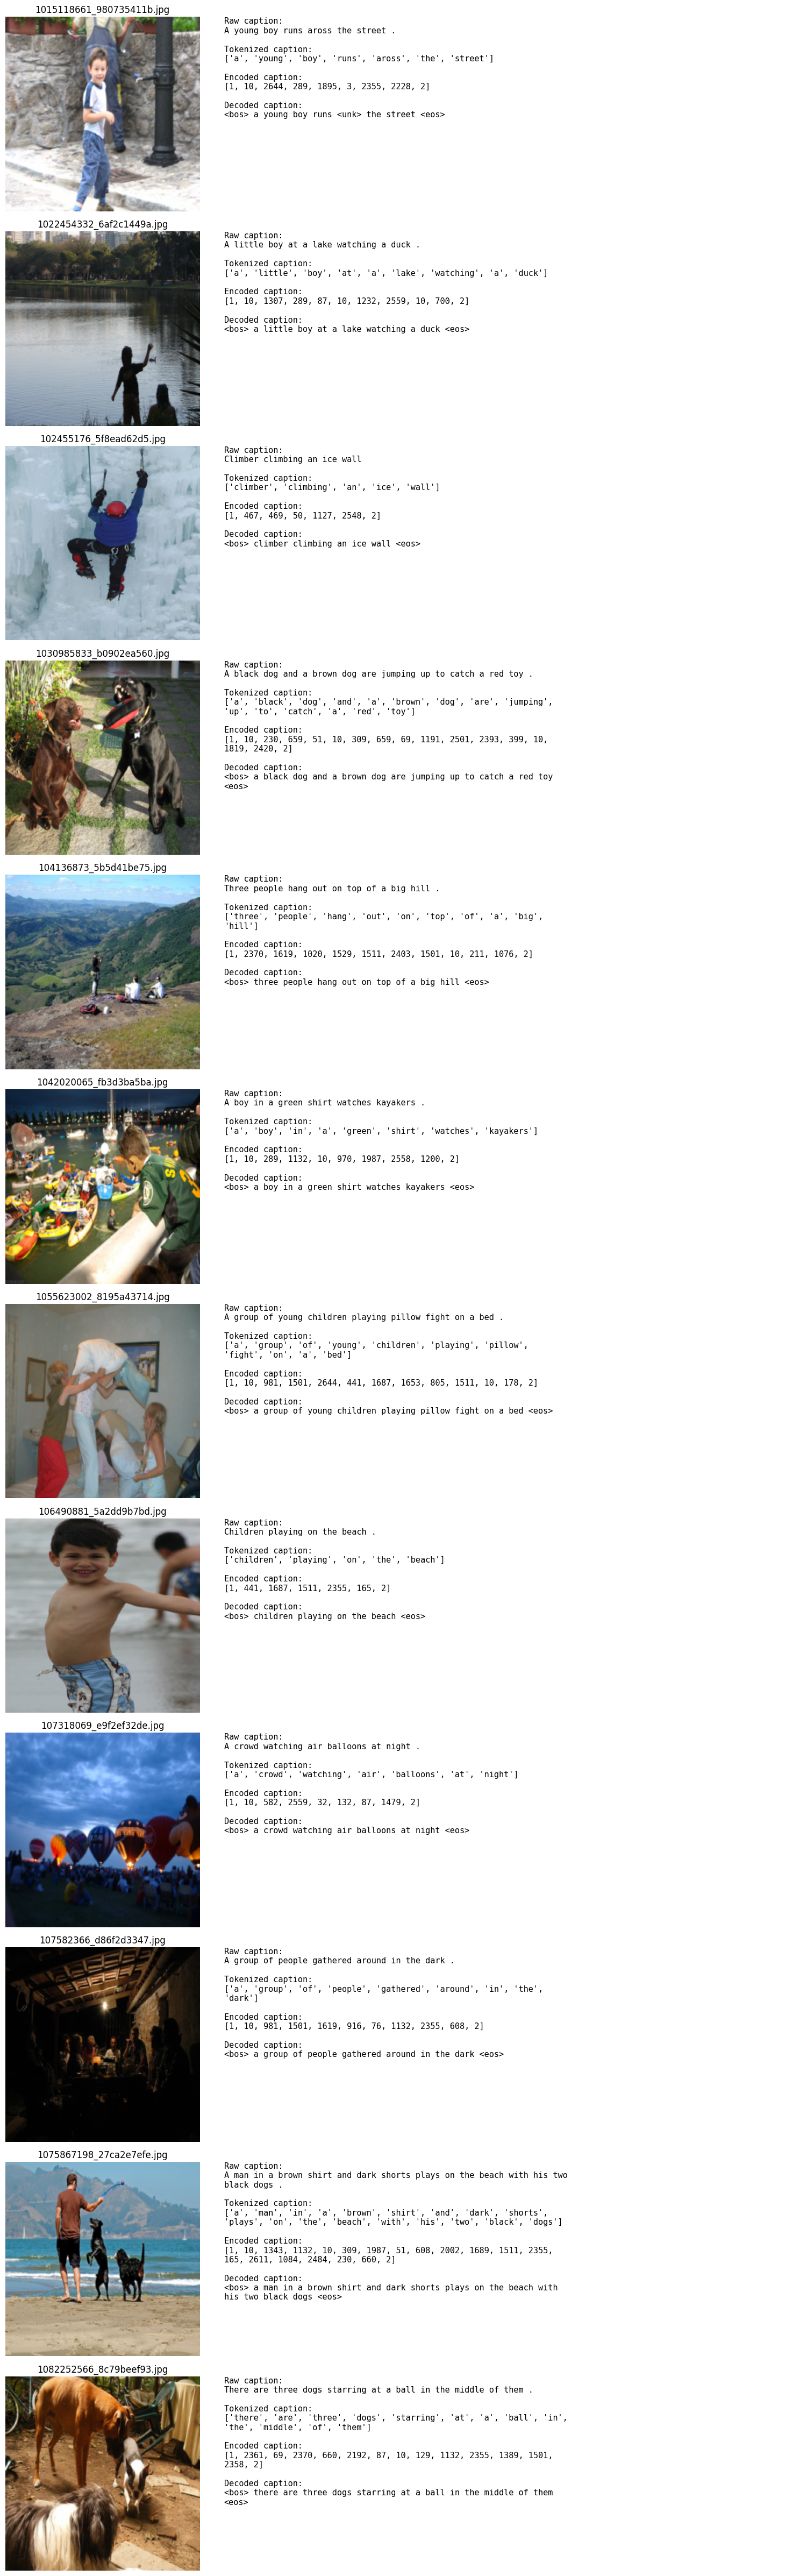

In [ ]:
num_examples = 12
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
)

if n == 1:
    axes = [axes]

for idx in range(n):
    image = denormalize_image(images[idx].detach().cpu()).permute(1, 2, 0)

    encoded_caption = captions[idx, : int(lengths[idx])].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption = tokenizer.decode(encoded_caption, skip_special_tokens=False)

    ax_image, ax_text = axes[idx]
    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx])
    ax_image.axis("off")

    caption_details = "\n\n".join(
        [
            f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=70)}",
            f"Tokenized caption:\n{textwrap.fill(str(tokenized_caption), width=70)}",
            f"Encoded caption:\n{textwrap.fill(str(encoded_caption), width=70)}",
            f"Decoded caption:\n{textwrap.fill(decoded_caption, width=70)}",
        ]
    )

    ax_text.axis("off")
    ax_text.text(
        0,
        1,
        caption_details,
        va="top",
        ha="left",
        fontsize=11,
        family="monospace",
    )

plt.tight_layout()
plt.show()

## Shared Utilities

Use this section for shared config and helper functions reused across all experiments. For example define a common training loop, BLEU computation or visualization helpers here. This way your model models stay directly comparable.


In [ ]:
# Define shared config, helper functions, a fixed evaluation subset, and BLEU computation.
DEVICE = None
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("device:", DEVICE)


# further helper functionality:
# ...

device: cuda


In [ ]:
import torch_directml
dml = torch_directml.device()
print("Device:", dml)   # should print "privateuseone:0"


Device: privateuseone:0


Helper

In [ ]:
def train_one_epoch(model, encoder, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for images, captions, lengths, _, _ in dataloader:
        images, captions = images.to(device), captions.to(device)

        optimizer.zero_grad()
        encoder_out = encoder(images)
        outputs = model(encoder_out, captions)
        targets = captions[:, 1:].contiguous()
        loss = criterion(outputs.view(-1, outputs.size(-1)), targets.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_one_epoch(model, encoder, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    hypotheses, references = [], []
    with torch.no_grad():
        for images, captions, lengths, _, raw_caps in dataloader:
            images, captions = images.to(device), captions.to(device)
            encoder_out = encoder(images)

            outputs = model(encoder_out, captions)
            targets = captions[:, 1:].contiguous()
            loss = criterion(outputs.view(-1, outputs.size(-1)), targets.view(-1))
            total_loss += loss.item()

            preds = model.generate(
                encoder_out,
                max_len=captions.size(1),
                bos_idx=tokenizer.bos_idx,
                eos_idx=tokenizer.eos_idx,
            )
            for pred in preds:
                hypotheses.append(tokenizer.decode(pred).split())
            references.extend([[ref.split()] for ref in raw_caps])
    return total_loss / len(dataloader), hypotheses, references

from nltk.translate.bleu_score import corpus_bleu
def compute_bleu(references, hypotheses):
    return {
        "BLEU-1": corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0)),
        "BLEU-2": corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0)),
        "BLEU-3": corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0)),
        "BLEU-4": corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25)),
    }

def show_image_with_caption(image_tensor, caption, tokenizer):
    image = denormalize_image(image_tensor.cpu())
    plt.imshow(image.permute(1, 2, 0))
    plt.title(tokenizer.decode(caption))
    plt.axis("off")
    plt.show()


## Model 1 - Show and Tell

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper . Record the training behavior, inspect a few generated captions on held-out images, and report BLEU on your fixed evaluation subset.

In [ ]:
# TODO Parameters for the Show and Tell architecture
ENCODER_DIM = 512      # ResNet18 output
EMBED_DIM = 256        # word embedding size
DECODER_DIM = 512      # LSTM hidden size
DROPOUT = 0.5          # dropout rate
FREEZE_ENCODER = True  # freeze CNN encoder initially


In [ ]:
# TODO Implement the Show and Tell model classes and any model-specific setup here.
import torch.nn as nn
import torchvision.models as models

class ShowAndTellEncoder(nn.Module):
    #def __init__(self,...):
        # TODO

    def __init__(self, encoder_dim=ENCODER_DIM, freeze_encoder=FREEZE_ENCODER):
        super().__init__()
        resnet = models.resnet18(pretrained=True)
        modules = list(resnet.children())[:-1]   # remove final FC
        self.cnn = nn.Sequential(*modules)

        if freeze_encoder:
            for p in self.cnn.parameters():
                p.requires_grad = False

        self.encoder_dim = encoder_dim
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # TODO
        features = self.cnn(images)              # (batch, 512, 1, 1)
        features = features.view(features.size(0), -1)  # (batch, 512)
        return features

class ShowAndTellCaptioner(nn.Module):
    #def __init__(self,...):
        # TODO
    def __init__(self, vocab_size, encoder_dim=ENCODER_DIM, embed_dim=EMBED_DIM,
                 decoder_dim=DECODER_DIM, dropout=DROPOUT):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim + encoder_dim, decoder_dim, batch_first=True)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, encoder_out: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # encoder_out: (batch, encoder_dim)
        # captions are expected to include <bos> and <eos> tokens.
        captions_input = captions[:, :-1]
        encoder_out = encoder_out.unsqueeze(1)  # (batch, 1, encoder_dim)
        embeddings = self.embed(captions_input)  # (batch, seq_len-1, embed_dim)
        inputs = torch.cat([encoder_out.expand(-1, embeddings.size(1), -1), embeddings], dim=-1)
        outputs, _ = self.lstm(inputs)
        outputs = self.dropout(outputs)
        logits = self.fc(outputs)          # (batch, seq_len-1, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, encoder_out: torch.Tensor, max_len=35, bos_idx=None, eos_idx=None):
        self.eval()
        batch_size = encoder_out.size(0)
        if bos_idx is None:
            bos_idx = tokenizer.bos_idx
        if eos_idx is None:
            eos_idx = tokenizer.eos_idx

        hidden = None
        bos_tokens = torch.tensor([bos_idx] * batch_size, device=encoder_out.device)
        inputs = torch.cat([encoder_out, self.embed(bos_tokens)], dim=-1).unsqueeze(1)
        captions = [[] for _ in range(batch_size)]

        for _ in range(max_len):
            outputs, hidden = self.lstm(inputs, hidden)
            outputs = self.fc(outputs.squeeze(1))  # (batch, vocab_size)
            predicted = outputs.argmax(dim=-1)     # greedy choice

            for i, p in enumerate(predicted.tolist()):
                captions[i].append(p)

            # stop if all EOS
            if all(p == eos_idx for p in predicted.tolist()):
                break

            inputs = torch.cat([encoder_out, self.embed(predicted)], dim=-1).unsqueeze(1)
        return captions

In [18]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 1 here and in the following cells.
import torch.optim as optim
import torch.nn as nn

# Initialize encoder + captioner
encoder = ShowAndTellEncoder(encoder_dim=ENCODER_DIM, freeze_encoder=FREEZE_ENCODER).to(DEVICE)
captioner = ShowAndTellCaptioner(
    vocab_size=len(tokenizer),
    encoder_dim=ENCODER_DIM,
    embed_dim=EMBED_DIM,
    decoder_dim=DECODER_DIM,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_idx)
optimizer = optim.Adam(captioner.parameters(), lr=1e-3)

NUM_EPOCHS = 10
train_losses, val_losses, bleu_scores = [], [], []

for epoch in range(NUM_EPOCHS):
    # Training
    train_loss = train_one_epoch(captioner, encoder, train_loader, criterion, optimizer, DEVICE)
    train_losses.append(train_loss)

    # Evaluation
    val_loss, hypotheses, references = evaluate_one_epoch(captioner, encoder, test_loader, criterion, DEVICE)
    val_losses.append(val_loss)
    bleu = compute_bleu(references, hypotheses)
    bleu_scores.append(bleu)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print("BLEU:", bleu)




/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


Epoch 1/10
Train Loss: 3.8280 | Val Loss: 3.2837
BLEU: {'BLEU-1': 0.20144927536231885, 'BLEU-2': 0.09699848642565839, 'BLEU-3': 0.050992290359977856, 'BLEU-4': 0.02631651764303199}
Epoch 2/10
Train Loss: 3.1826 | Val Loss: 3.0067
BLEU: {'BLEU-1': 0.22522239665096805, 'BLEU-2': 0.11471269985872415, 'BLEU-3': 0.06197925943097947, 'BLEU-4': 0.03275676707634682}
Epoch 3/10
Train Loss: 2.9716 | Val Loss: 2.9458
BLEU: {'BLEU-1': 0.1849768942366379, 'BLEU-2': 0.09164374329866204, 'BLEU-3': 0.04861922622738125, 'BLEU-4': 0.024081912937536823}
Epoch 4/10
Train Loss: 2.8420 | Val Loss: 2.8535
BLEU: {'BLEU-1': 0.18590143480973179, 'BLEU-2': 0.09544531718486517, 'BLEU-3': 0.054041171326075964, 'BLEU-4': 0.03009713929831299}
Epoch 5/10
Train Loss: 2.7473 | Val Loss: 2.8212
BLEU: {'BLEU-1': 0.234117568672958, 'BLEU-2': 0.1224939816964906, 'BLEU-3': 0.0679063489788903, 'BLEU-4': 0.036448511726018436}
Epoch 6/10
Train Loss: 2.6712 | Val Loss: 2.8249
BLEU: {'BLEU-1': 0.22551418901327783, 'BLEU-2': 0.11

In [19]:
images, captions, lengths, _, raw_caps = next(iter(test_loader))
images = images.to(DEVICE)
encoder_out = encoder(images)

# Generate captions
generated = captioner.generate(encoder_out, max_len=MAX_LEN)

# Show a few examples
for i in range(3):
    print("Reference:", raw_caps[i])
    print("Generated:", tokenizer.decode(generated[i]))
    print("---")


Reference: A young boy runs aross the street .
Generated: a man in a blue shirt and a blue shirt is standing on a sidewalk
---
Reference: a large lake with a lone duck swimming in it with several people around the edge of it .
Generated: a man in a black shirt and a black dog jumping into the water
---
Reference: an ice climber in a blue jacket and black pants is scaling a frozen ice wall .
Generated: a man in a red jacket is standing in the snow
---


Briefly summarize what happened during training, which captions looked convincing or weak, and what the BLEU score does or does not capture for this model.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 1 here.</span>


## Model 2 - Show, Attend and Tell

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044). Use the same test data subset and BLEU setup as before, then compare how attention changes the training behavior and generated captions.


In [ ]:
# TODO Parameters for the Show, Attend and Tell Architecture
ENCODER_DIM =
EMBED_DIM =
DECODER_DIM =
DROPOUT =
FREEZE_ENCODER =
ATTENTION_DIM =

In [ ]:
class ShowAttendTellEncoder(nn.Module):
    def __init__(self, ...):
        # TODO
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # TODO


class AdditiveAttention(nn.Module):
    def __init__(self, ....):
        # TODO
    def forward(self, encoder_out: torch.Tensor, decoder_hidden: torch.Tensor):
        # encoder_out: (B, num_pixels, encoder_dim)
        # decoder_hidden: (B, decoder_dim)
        # TODO

class ShowAttendTellCaptioner(nn.Module):
    def __init__(self, ...):
        # TODO

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # TODO

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        # TODO

In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 2 here and in the following cells.

Briefly summarize how this model behaved during training, where attention seemed to help or fail, and how the BLEU score compares to Model 2.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 2 here.</span>


## Additional Task 1: Option ...

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it.

## Additional Task 2: Option ....

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it.